In [1]:
import torch

from dataset_loaders import build_data_loaders
from utils.checkpoints import load_ae_from_path, load_from_wandb
from utils.config import DatasetConfig
from utils.visualisation import show

In [2]:
ae_path = load_from_wandb("autoencoder_cub200")
ae = load_ae_from_path(ae_path, device=torch.device("mps"))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /Users/jakob/.netrc.


Loading /Users/jakob/Studium/Thesis/master-thesis/artifacts/autoencoder_cub200_beta1.0.pt from Weights & Biases artifact jmartini-tu-darmstadt/master-thesis/autoencoder_cub200:latest


In [3]:
dataset_cfg = DatasetConfig(
    name="cub200",
    channels=3,
    height=128,
    width=128,
    num_classes=200,
)

dataloader, test_loader = build_data_loaders(dataset_cfg, batch_size=64, shuffle_test=True)


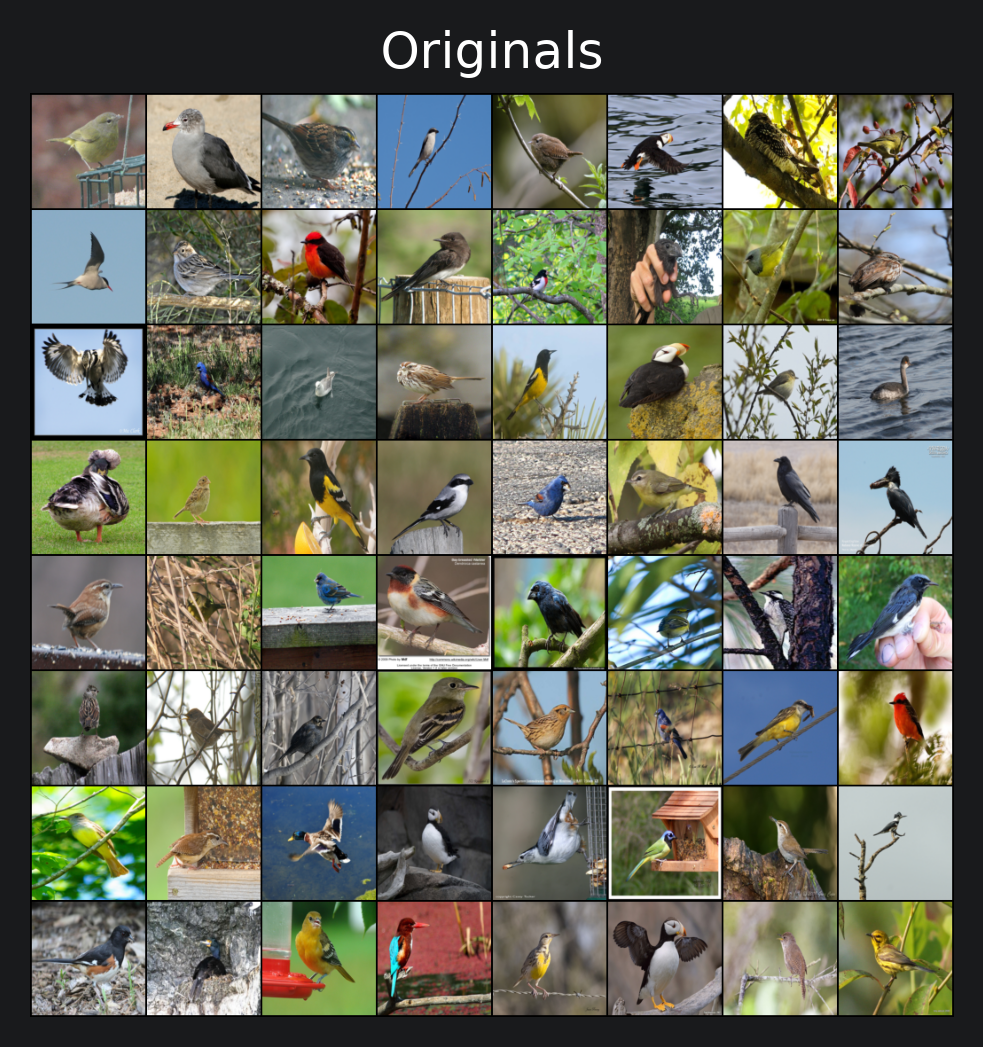

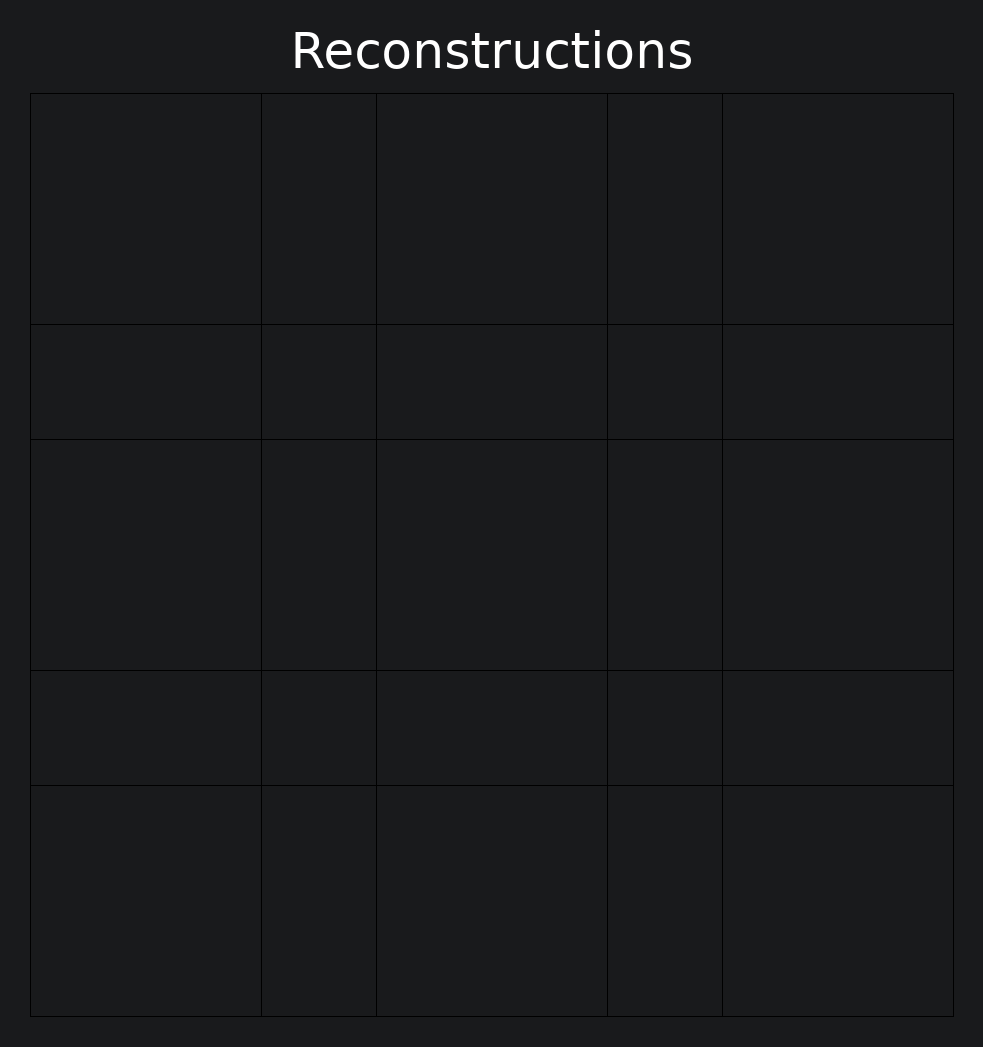

In [6]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    logits, mu, logvar = ae(images)
    recon = torch.sigmoid(logits)

#print(recon[0])
show(images, "Originals")
show(recon, "Reconstructions")
